### Librarys

In [560]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

### Load Data 

In [561]:
df = pd.read_csv("Mall_Customers.csv")

df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


### Understand Data

In [562]:
df.tail()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


### drop Customer ID

In [563]:
df.drop("CustomerID",axis = 1,inplace = True)

### Find Outlier 

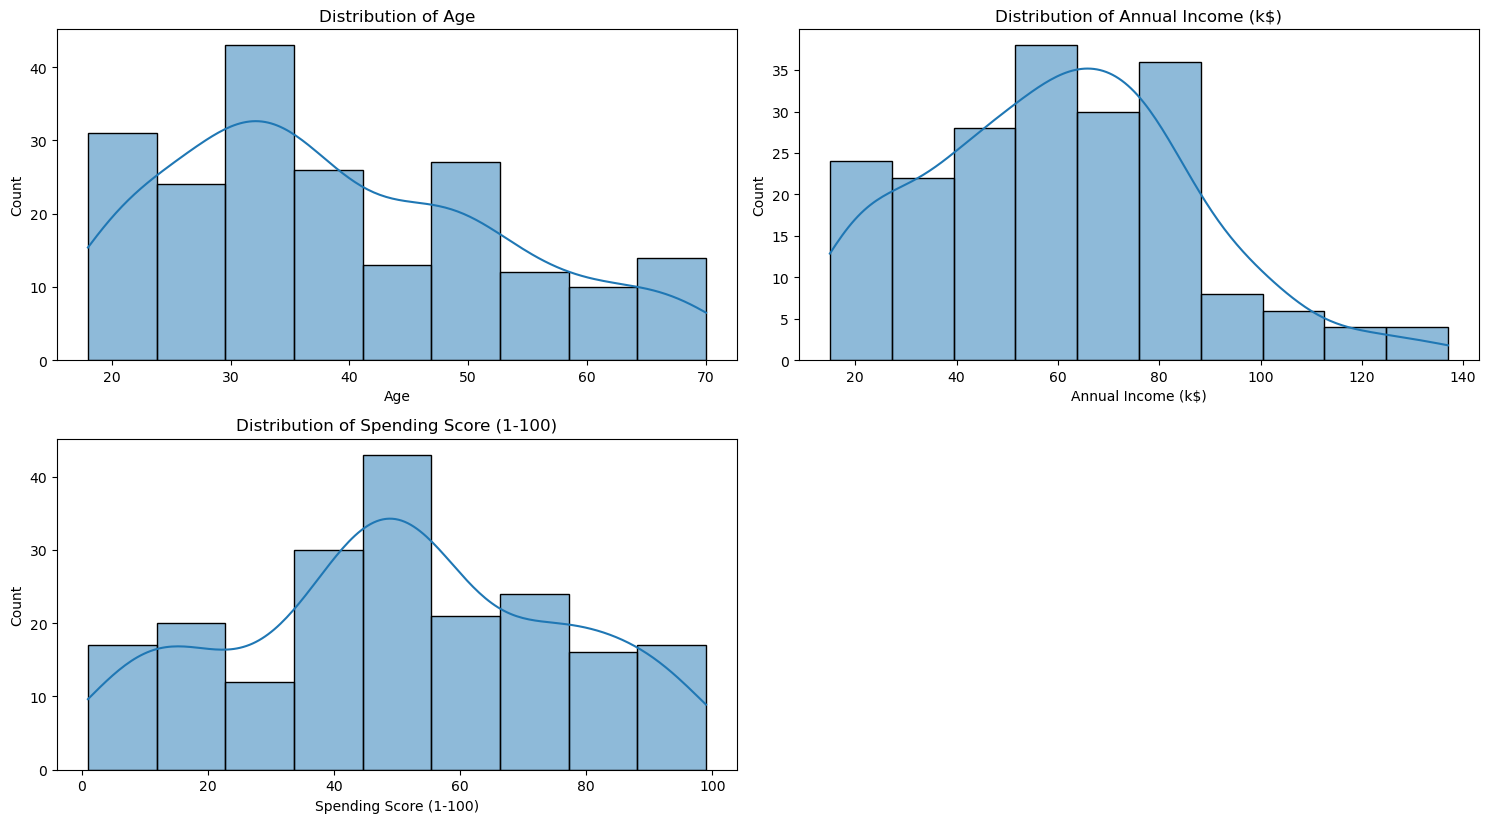

In [564]:
Numerical_columns = ["Age","Annual Income (k$)","Spending Score (1-100)"]
plt.figure(figsize=(15,12))
for i, col in enumerate(Numerical_columns, 1):
    plt.subplot(3,2,i) 
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

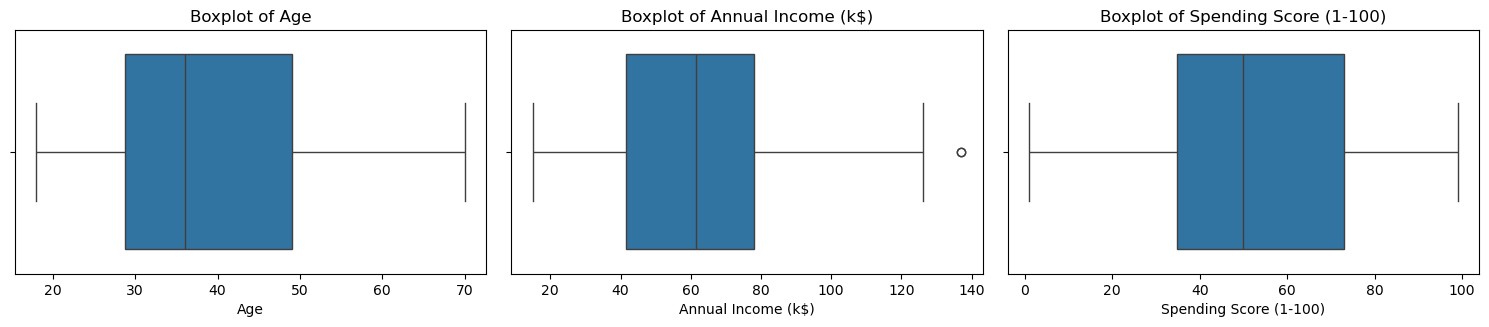

In [565]:
Numerical_columns = ["Age","Annual Income (k$)","Spending Score (1-100)"]
plt.figure(figsize=(15,12))
for i, col in enumerate(Numerical_columns, 1):
    plt.subplot(4,3,i)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

No Outliers effect in model in Annual Income (k$) thats logical Outlier

### Feature Encoding 

In [566]:
Label = LabelEncoder()

df["Gender"] = Label.fit_transform(df["Gender"])
df

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40
...,...,...,...,...
195,0,35,120,79
196,0,45,126,28
197,1,32,126,74
198,1,32,137,18


### Data Scalling

In [567]:
X = df[["Annual Income (k$)","Spending Score (1-100)"]]

Scaler = StandardScaler()

X = Scaler.fit_transform(X)

### Elbow Method to Know how Many segments or Clusters

c:\Users\work\anaconda3\envs\tf\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\work\anaconda3\envs\tf\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\work\anaconda3\envs\tf\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\work\anaconda3\envs\tf\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to 

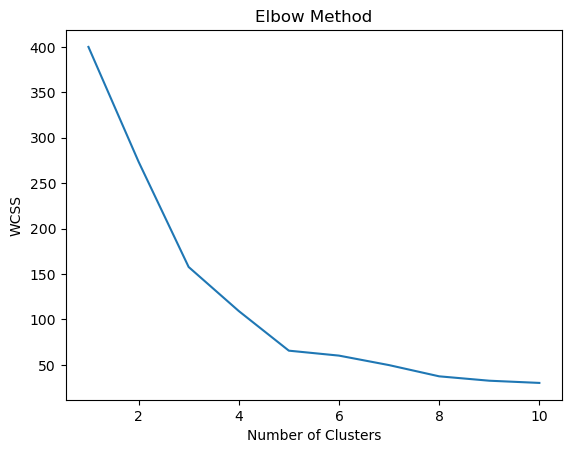

In [568]:
wcss = []

K_Rng = range(1,11)

for i in K_Rng:
    Kmeans = KMeans(n_clusters = i , random_state = 42)
    Kmeans.fit(X)
    wcss.append(Kmeans.inertia_)



plt.plot(K_Rng, wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

so the number of clusters or segments in this problem and has the lowest Sum of Sqaured is 5

### Kmeans Algorithm

In [569]:
Kmeans = KMeans(n_clusters = 5 , random_state = 42)

labels = Kmeans.fit_predict(X)

df["clusters"] = labels

df

c:\Users\work\anaconda3\envs\tf\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,Gender,Age,Annual Income (k$),Spending Score (1-100),clusters
0,1,19,15,39,4
1,1,21,15,81,2
2,0,20,16,6,4
3,0,23,16,77,2
4,0,31,17,40,4
...,...,...,...,...,...
195,0,35,120,79,1
196,0,45,126,28,3
197,1,32,126,74,1
198,1,32,137,18,3


### Evaluate Model

[[-0.20091257 -0.02645617]
 [ 0.99158305  1.23950275]
 [-1.32954532  1.13217788]
 [ 1.05500302 -1.28443907]
 [-1.30751869 -1.13696536]]
Silhouette Score: 0.5546571631111091


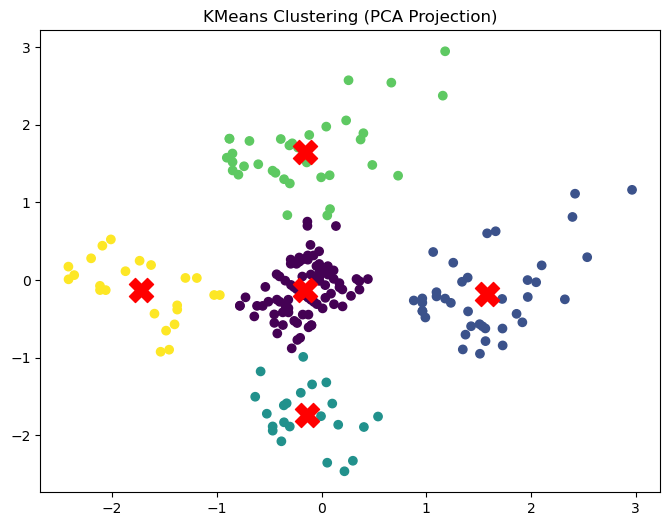

In [570]:
print(Kmeans.cluster_centers_)

score = silhouette_score(X, labels)
print("Silhouette Score:", score)



from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,6))

plt.scatter(X_pca[:, 0], 
            X_pca[:, 1], 
            c=labels, 
            cmap='viridis')

centers_pca = pca.transform(Kmeans.cluster_centers_)

plt.scatter(centers_pca[:, 0],
            centers_pca[:, 1],
            s=300,
            c='red',
            marker='X')

plt.title("KMeans Clustering (PCA Projection)")
plt.show()


### Analyze Spending 

In [571]:
df.groupby("clusters")["Spending Score (1-100)"].mean()

clusters
0    49.518519
1    82.128205
2    79.363636
3    17.114286
4    20.913043
Name: Spending Score (1-100), dtype: float64

### DBSCAN Algorithm

BOUNS

In [572]:
db = DBSCAN(eps = .4 , min_samples = 5)

labels = db.fit_predict(X)

df["Cluster"] = labels
df

,Gender,Age,Annual Income (k$),Spending Score (1-100),clusters,Cluster
0,1,19,15,39,4,0
1,1,21,15,81,2,0
2,0,20,16,6,4,1
3,0,23,16,77,2,0
4,0,31,17,40,4,0
...,...,...,...,...,...,...
195,0,35,120,79,1,-1
196,0,45,126,28,3,-1
197,1,32,126,74,1,-1
198,1,32,137,18,3,-1


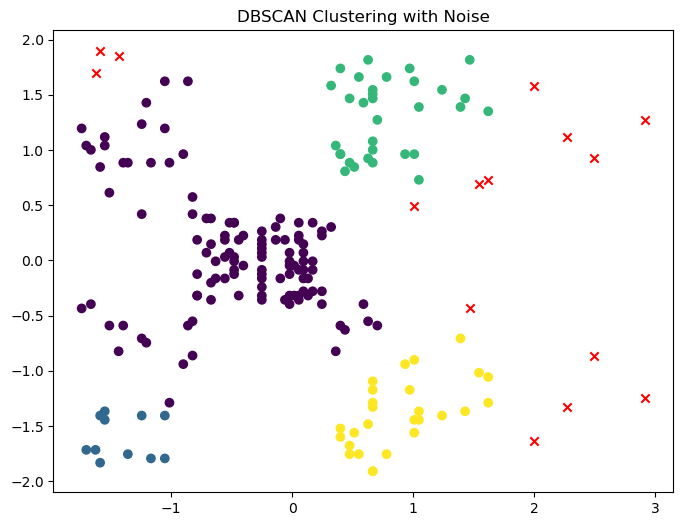

Silhouette Score: 0.4780592455223124


In [573]:
plt.figure(figsize=(8,6))

plt.scatter(X[labels != -1, 0],
            X[labels != -1, 1],
            c=labels[labels != -1],
            cmap='viridis')

plt.scatter(X[labels == -1, 0],
            X[labels == -1, 1],
            c='red',
            marker='x')

plt.title("DBSCAN Clustering with Noise")
plt.show()




score = silhouette_score(X[labels != -1], labels[labels != -1])

print("Silhouette Score:", score)


Kmeans has highest Silhouette  = .55 and DBSCAN  = .47 

So Kmeans is th best Algo for this Problem Set

so the Problem Dataset is sperichal dataset -----> KMeans